# Import Libraries

In [1]:
import sys
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from wordcloud import WordCloud

#  Load Dataset

In [2]:
def get_project_root() -> Path:
    """Finds the root directory of the project using root markers."""
    current = Path(__file__).resolve() if '__file__' in globals() else Path.cwd().resolve()
    
    markers = [".git", "pyproject.toml", "requirements.txt", "uv.lock"]
    
    for parent in [current] + list(current.parents):
        if any((parent / marker).exists() for marker in markers):
            return parent
            
    if current.name == "Notebook":
        return current.parent
        
    return current

PROJECT_ROOT = get_project_root()
DATA_DIR = PROJECT_ROOT / "Data"
MODEL_DIR = PROJECT_ROOT / "Model"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

csv_path = DATA_DIR / "IMDB Dataset.csv"
df = pd.read_csv(csv_path)

print("Project Root:", PROJECT_ROOT)
print("Data Path:", csv_path)
print("Data loaded successfully! Shape:", df.shape)

Project Root: D:\classical-nlp-streamlit-project\nlp-project
Data Path: D:\classical-nlp-streamlit-project\nlp-project\Data\IMDB Dataset.csv
Data loaded successfully! Shape: (50000, 2)


#  Dataset Overview

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [6]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [7]:
df.shape

(50000, 2)

# Identify and Remove Exact Duplicates and Null Values

In [8]:
df.sentiment.value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [9]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [10]:
df.duplicated().sum()

418

In [11]:
df = df.dropna().drop_duplicates().reset_index(drop=True)

# Same review text with two different labels would confuse the model
conflicting = df[df.duplicated("review", keep=False)]
print("Reviews with conflicting labels:", conflicting["review"].nunique())
df = df.drop_duplicates("review", keep=False).reset_index(drop=True) if len(conflicting) else df

Reviews with conflicting labels: 0


In [12]:
print("Shape after cleaning:", df.shape)
print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

Shape after cleaning: (49582, 2)

Sentiment distribution:
sentiment
positive    24884
negative    24698
Name: count, dtype: int64


# Basic Visualizations

## Sentiment distribution

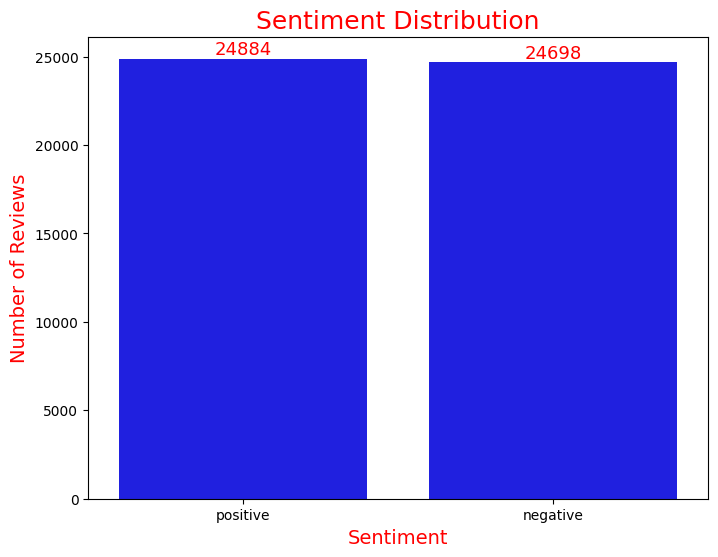

In [13]:
plt.figure(figsize=(8,6))

ax = sns.countplot(
    data=df,
    x="sentiment",
    color = 'blue'
)

for x in ax.containers :
    ax.bar_label(x, color = 'red', fontsize = 13)

plt.title("Sentiment Distribution", color = 'red', fontsize = 18)
plt.xlabel("Sentiment", color = 'red', fontsize = 14)
plt.ylabel("Number of Reviews", color = 'red', fontsize = 14)

plt.show()

## Review Length, Word Count, Character Count

## Create Text Statistics

Statistics are computed after removing HTML tags such as `<br />`, so they describe the actual review text.

In [14]:
from utils.text_preprocessing import strip_html

review_text = df["review"].apply(strip_html)

df["char_count"] = review_text.str.len()

df["word_count"] = (
    review_text
    .str.split()
    .str.len()
)

df["char_count_no_spaces"] = (
    review_text
    .str.replace(r"\s+", "", regex=True)
    .str.len()
)

def count_sentences(text):
    sentences = re.split(r"[.!?]+", text)
    return sum(bool(sentence.strip()) for sentence in sentences)

df["sentence_count"] = review_text.apply(count_sentences)

In [15]:
df.head()

,review,sentiment,char_count,word_count,char_count_no_spaces,sentence_count
0,One of the other reviewers has mentioned that ...,positive,1731,304,1425,17
1,A wonderful little production. <br /><br />The...,positive,968,156,807,7
2,I thought this was a wonderful way to spend ti...,positive,906,164,741,7
3,Basically there's a family where a little boy ...,negative,718,135,581,10
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1277,225,1048,15


In [16]:
df[[
    "char_count",
    "word_count",
    "char_count_no_spaces",
    "sentence_count"
]].describe()

,char_count,word_count,char_count_no_spaces,sentence_count
count,49582.000000,49582.000000,49582.000000,49582.000000
mean,1290.349825,229.059054,1059.977976,13.261022
std,975.234955,169.788967,804.344057,9.276360
min,32.000000,4.000000,27.000000,1.000000
25%,691.000000,125.000000,565.000000,7.000000
50%,957.000000,172.000000,785.000000,11.000000
75%,1564.000000,278.000000,1286.000000,16.000000
max,13604.000000,2459.000000,11135.000000,150.000000


## Character Count

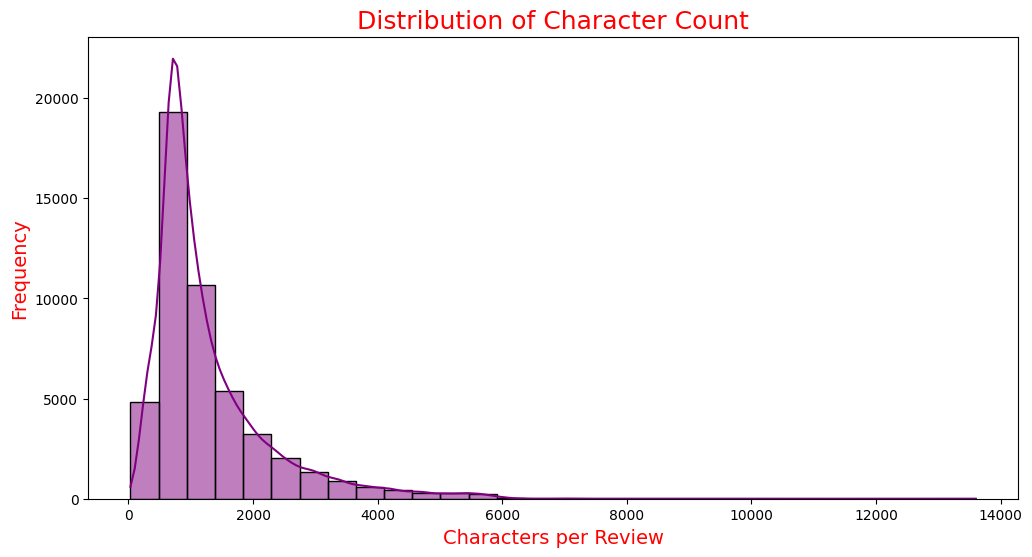

In [17]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="char_count",
    bins=30,
    kde=True,
    color = 'purple'
)

plt.title("Distribution of Character Count", color = 'red', fontsize = 18)
plt.xlabel("Characters per Review", color = 'red', fontsize = 14)
plt.ylabel("Frequency", color = 'red', fontsize = 14)

plt.show()

## Word Count Distribution

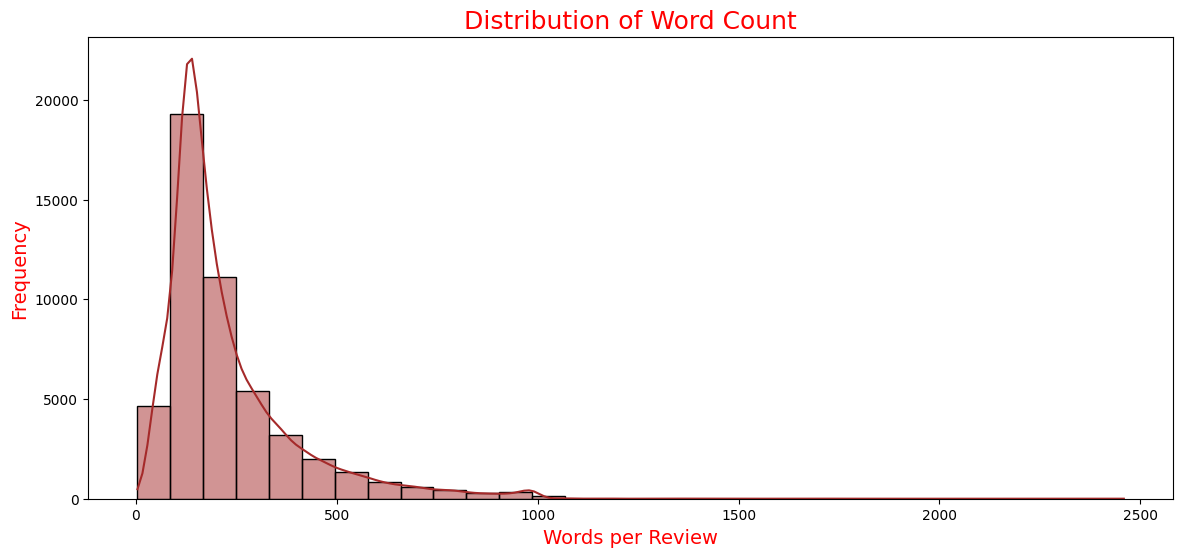

In [18]:
plt.figure(figsize=(14,6))

sns.histplot(
    data=df,
    x="word_count",
    bins=30,
    kde=True,
    color = 'brown'
)

plt.title("Distribution of Word Count", color = 'red', fontsize = 18)
plt.xlabel("Words per Review", color = 'red', fontsize = 14)
plt.ylabel("Frequency", color = 'red', fontsize = 14)

plt.show()

## Sentence Count

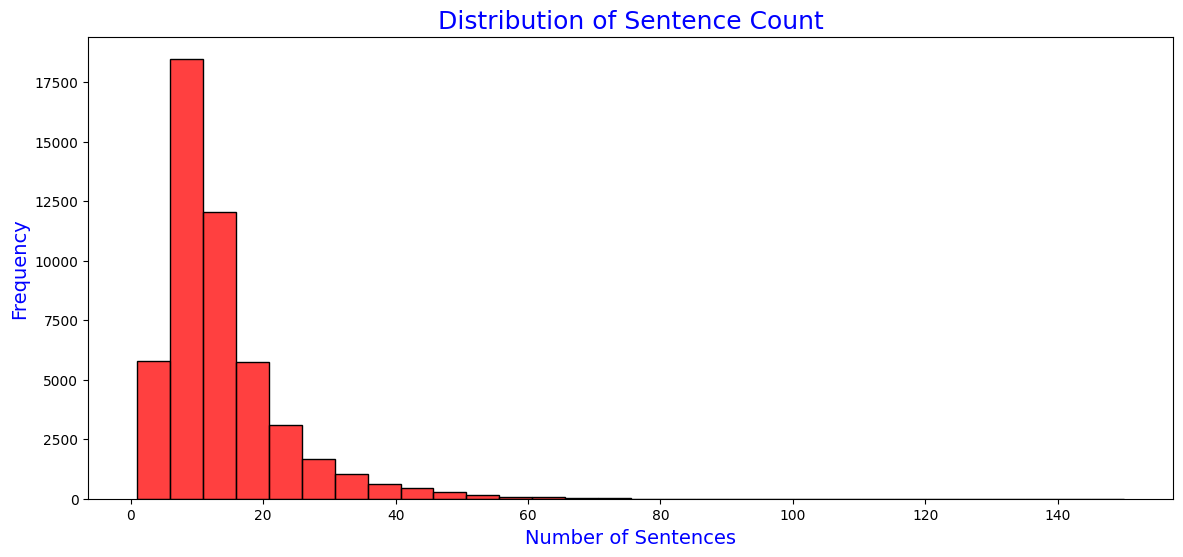

In [19]:
plt.figure(figsize=(14,6))

sns.histplot(
    data=df,
    x="sentence_count",
    bins=30,
    color = 'red'
)

plt.title("Distribution of Sentence Count", color = 'blue', fontsize = 18)
plt.xlabel("Number of Sentences", color = 'blue', fontsize = 14)
plt.ylabel("Frequency", color = 'blue', fontsize = 14)

plt.show()

# Text Exploration

## Positive vs Negative Review Length

Min : 65
Mean: 1306.7
Max : 13604


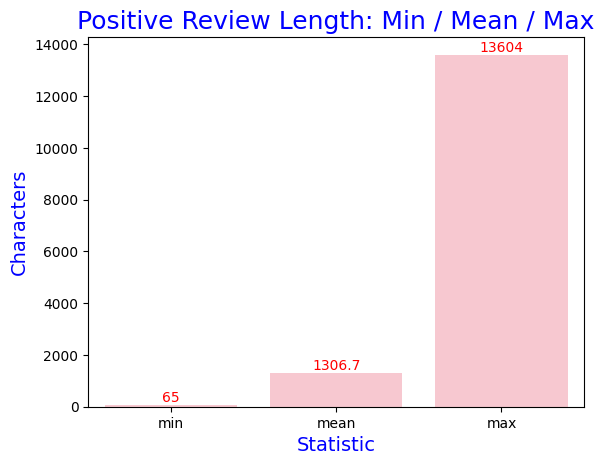

In [20]:
pos_len = df.loc[df.sentiment == 'positive', 'char_count']

pos_min = int(pos_len.min())
pos_avg = round(pos_len.mean(), 1)
pos_max = int(pos_len.max())

print("Min :", pos_min)
print("Mean:", pos_avg)
print("Max :", pos_max)

label = ['min', 'mean', 'max']
score = [pos_min, pos_avg, pos_max]

ax = sns.barplot(x = label, y = score, color = 'pink')
for x in ax.containers :
    ax.bar_label(x, color = 'red', fontsize = 10)

plt.title("Positive Review Length: Min / Mean / Max", color = 'blue', fontsize = 18)
plt.xlabel("Statistic", color = 'blue', fontsize = 14)
plt.ylabel("Characters", color = 'blue', fontsize = 14)

plt.show()

Min : 32
Mean: 1273.9
Max : 8729


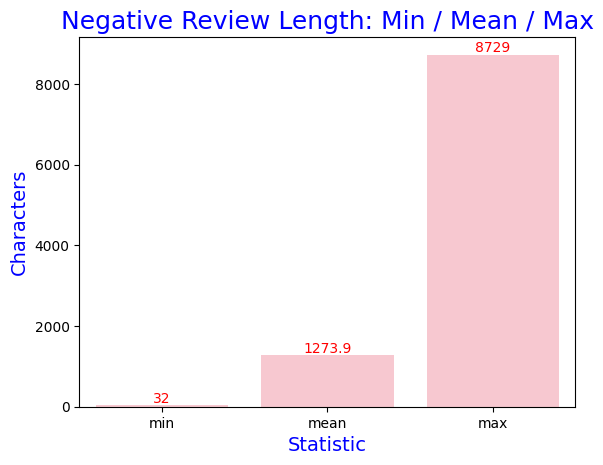

In [21]:
neg_len = df.loc[df.sentiment == 'negative', 'char_count']

neg_min = int(neg_len.min())
neg_avg = round(neg_len.mean(), 1)
neg_max = int(neg_len.max())

print("Min :", neg_min)
print("Mean:", neg_avg)
print("Max :", neg_max)

label = ['min', 'mean', 'max']
score = [neg_min, neg_avg, neg_max]

ax = sns.barplot(x = label, y = score, color = 'pink')
for x in ax.containers :
    ax.bar_label(x, color = 'red', fontsize = 10)

plt.title("Negative Review Length: Min / Mean / Max", color = 'blue', fontsize = 18)
plt.xlabel("Statistic", color = 'blue', fontsize = 14)
plt.ylabel("Characters", color = 'blue', fontsize = 14)

plt.show()

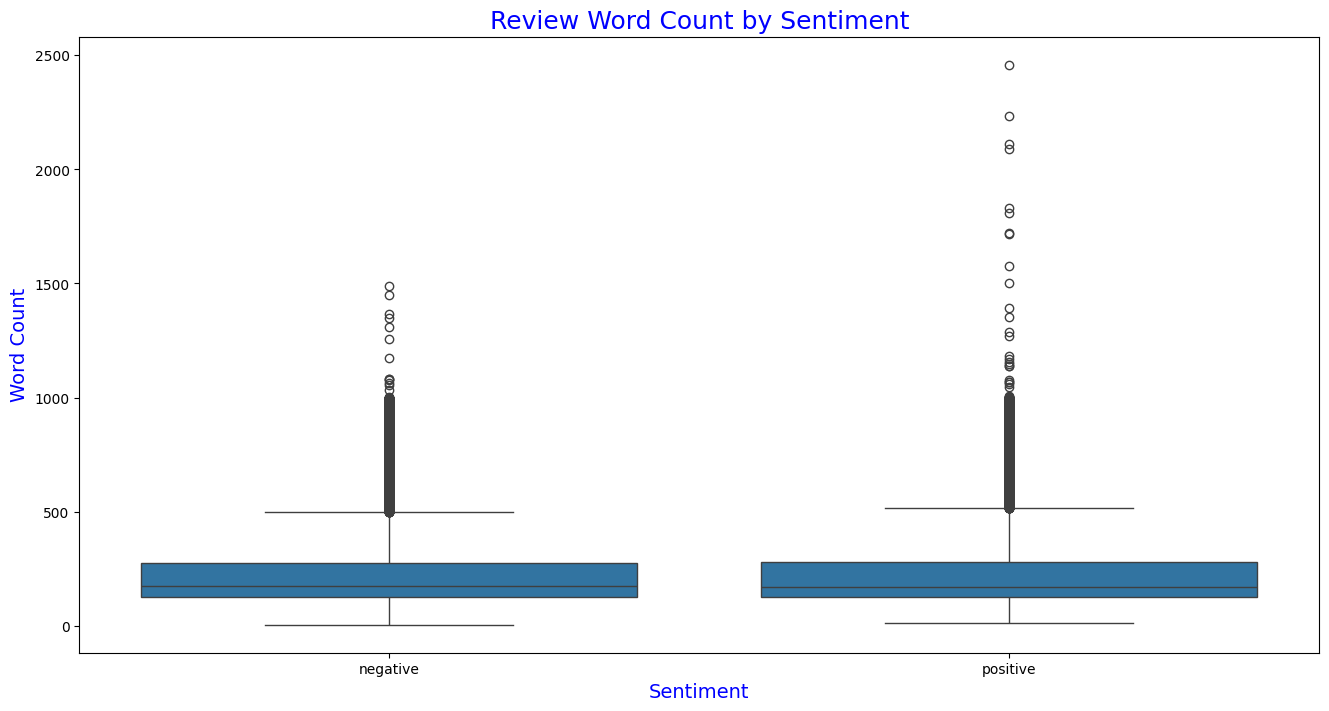

In [22]:
plt.figure(figsize=(16,8))

sns.boxplot(
    data=df,
    x="sentiment",
    y="word_count",
    order=["negative", "positive"]
)

plt.title("Review Word Count by Sentiment", color = 'blue', fontsize = 18)
plt.xlabel("Sentiment", color = 'blue', fontsize = 14)
plt.ylabel("Word Count", color = 'blue', fontsize = 14)

plt.show()

# Text Preprocessing

The cleaning functions live in `utils/text_preprocessing.py` so the notebook, the model training and the Streamlit app all use exactly the same code.

In [23]:
from utils.text_preprocessing import (
    clean_text,
    lemmatize_text,
    CONTRACTIONS,
    KEEP_WORDS,
    ENGLISH_STOPWORDS,
)

print("Negation / sentiment words kept:", sorted(KEEP_WORDS))
print("Stopwords removed:", len(ENGLISH_STOPWORDS))
print("Contractions expanded:", len(CONTRACTIONS))

Negation / sentiment words kept: ['against', 'but', 'never', 'no', 'nor', 'not', 'only', 'too', 'very']
Stopwords removed: 190
Contractions expanded: 21


In [24]:
df["clean_review"] = df["review"].apply(clean_text)

# Reviews that become empty after cleaning would be saved as NaN in the CSV
empty = (df["clean_review"].str.strip() == "").sum()
print("Empty reviews after cleaning:", empty)
df = df[df["clean_review"].str.strip() != ""].reset_index(drop=True)

df.head()

Empty reviews after cleaning: 0


,review,sentiment,char_count,word_count,char_count_no_spaces,sentence_count,clean_review
0,One of the other reviewers has mentioned that ...,positive,1731,304,1425,17,one reviewers mentioned watching oz episode ho...
1,A wonderful little production. <br /><br />The...,positive,968,156,807,7,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,906,164,741,7,thought wonderful way spend time too hot summe...
3,Basically there's a family where a little boy ...,negative,718,135,581,10,basically family little boy jake thinks zombie...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1277,225,1048,15,petter mattei love time money visually stunnin...


In [25]:
print("Original:")
print(df["review"].iloc[0])

print("\nCleaned:")
print(df["clean_review"].iloc[0])

Original:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due 

# Top Words Overall

In [26]:
all_words = " ".join(
    df["clean_review"]
).split()

word_freq = Counter(all_words)

top_words = word_freq.most_common(20)

words = [x[0] for x in top_words]
counts = [x[1] for x in top_words]

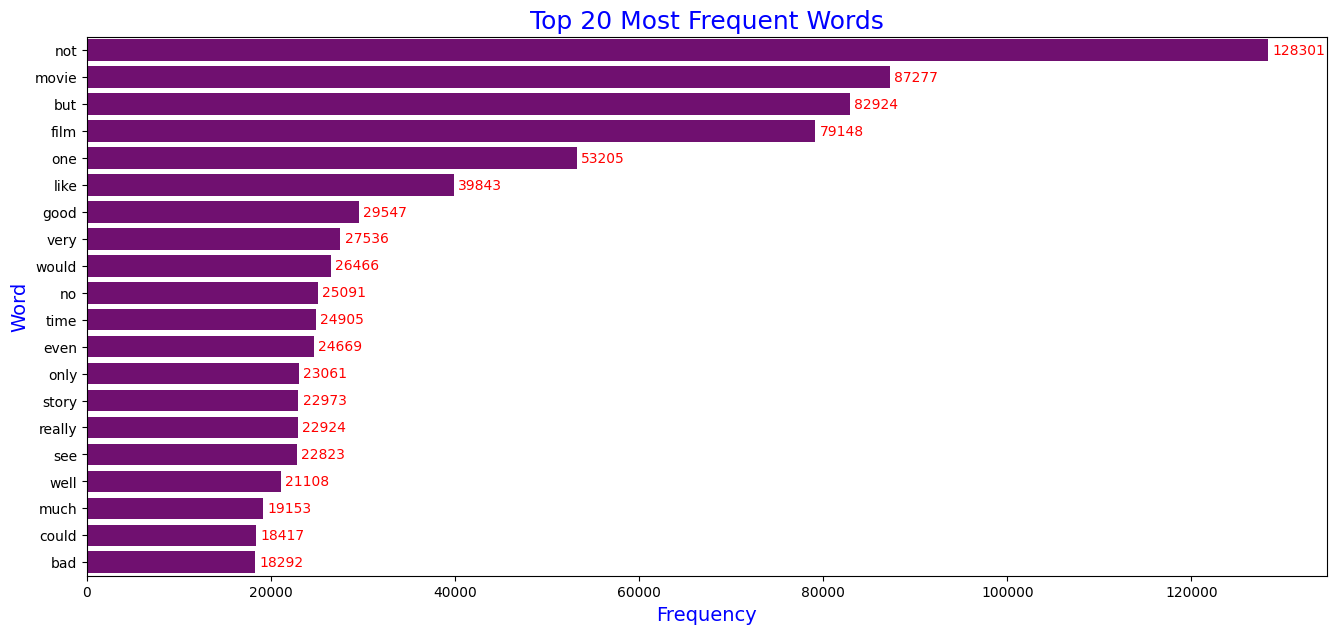

In [27]:
plt.figure(figsize=(16,7))

ax = sns.barplot(
    x=counts,
    y=words,
    color = 'purple'
)


for x in ax.containers :
    ax.bar_label(x, color = 'red', fontsize = 10, padding = 3)


plt.title("Top 20 Most Frequent Words", color = 'blue', fontsize = 18)
plt.xlabel("Frequency", color = 'blue', fontsize = 14)
plt.ylabel("Word", color = 'blue', fontsize = 14)

plt.show()

# Positive Words

In [28]:
positive_text = " ".join(
    df.loc[
        df["sentiment"] == "positive",
        "clean_review"
    ]
)

positive_words = Counter(
    positive_text.split()
)

top_positive = positive_words.most_common(20)

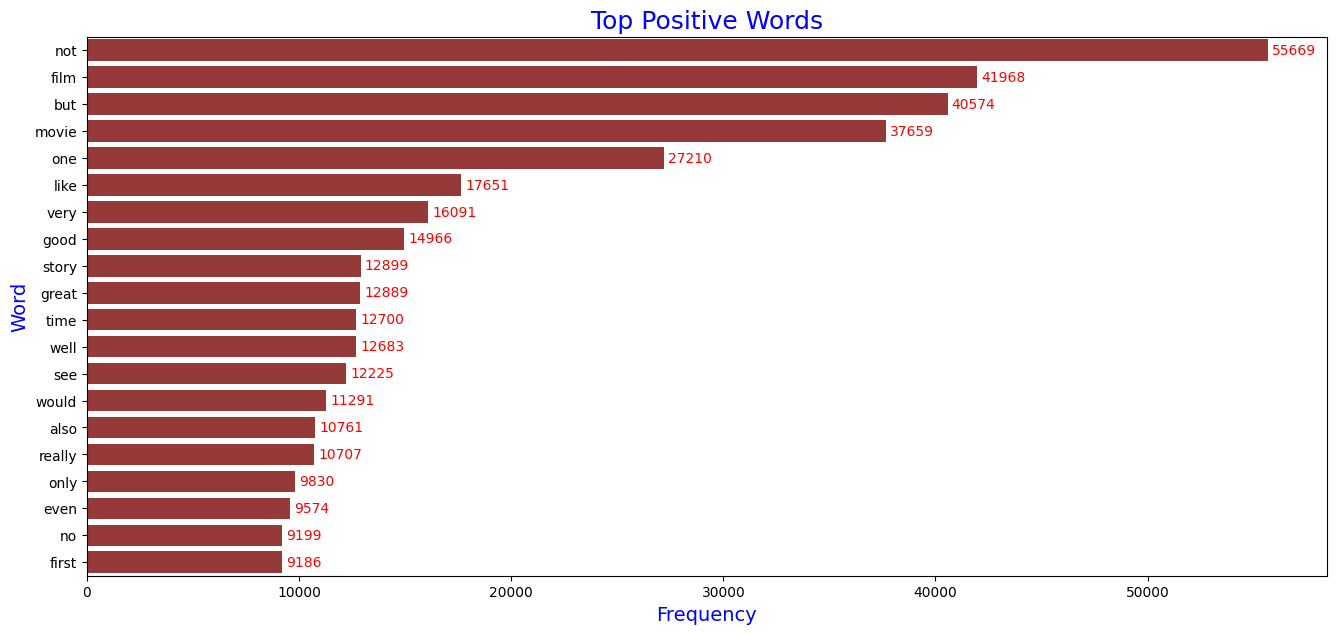

In [29]:
words = [x[0] for x in top_positive]
counts = [x[1] for x in top_positive]

plt.figure(figsize=(16,7))

ax = sns.barplot(
    x=counts,
    y=words,
    color = 'brown'
)

for x in ax.containers :
    ax.bar_label(x, color = 'red', fontsize = 10, padding = 3)

plt.title("Top Positive Words", color = 'blue', fontsize = 18)
plt.xlabel("Frequency", color = 'blue', fontsize = 14)
plt.ylabel("Word", color = 'blue', fontsize = 14)

plt.show()

# Negative Words

In [30]:
negative_text = " ".join(
    df.loc[
        df["sentiment"] == "negative",
        "clean_review"
    ]
)

negative_words = Counter(
    negative_text.split()
)

top_negative = negative_words.most_common(20)

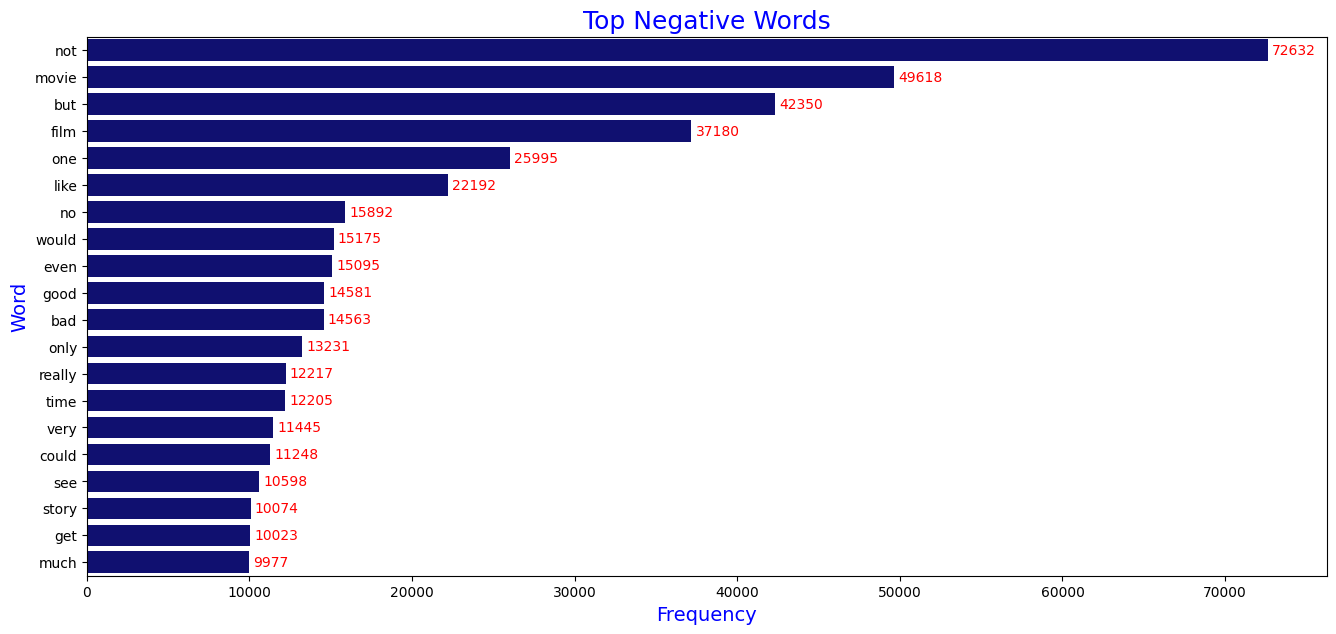

In [31]:
words = [x[0] for x in top_negative]
counts = [x[1] for x in top_negative]

plt.figure(figsize=(16,7))

ax = sns.barplot(
    x=counts,
    y=words,
    color = 'navy'
)


for x in ax.containers :
    ax.bar_label(x, color = 'red', fontsize = 10, padding = 3)

plt.title("Top Negative Words", color = 'blue', fontsize = 18)
plt.xlabel("Frequency", color = 'blue', fontsize = 14)
plt.ylabel("Word", color = 'blue', fontsize = 14)

plt.show()

# Overall WordCloud

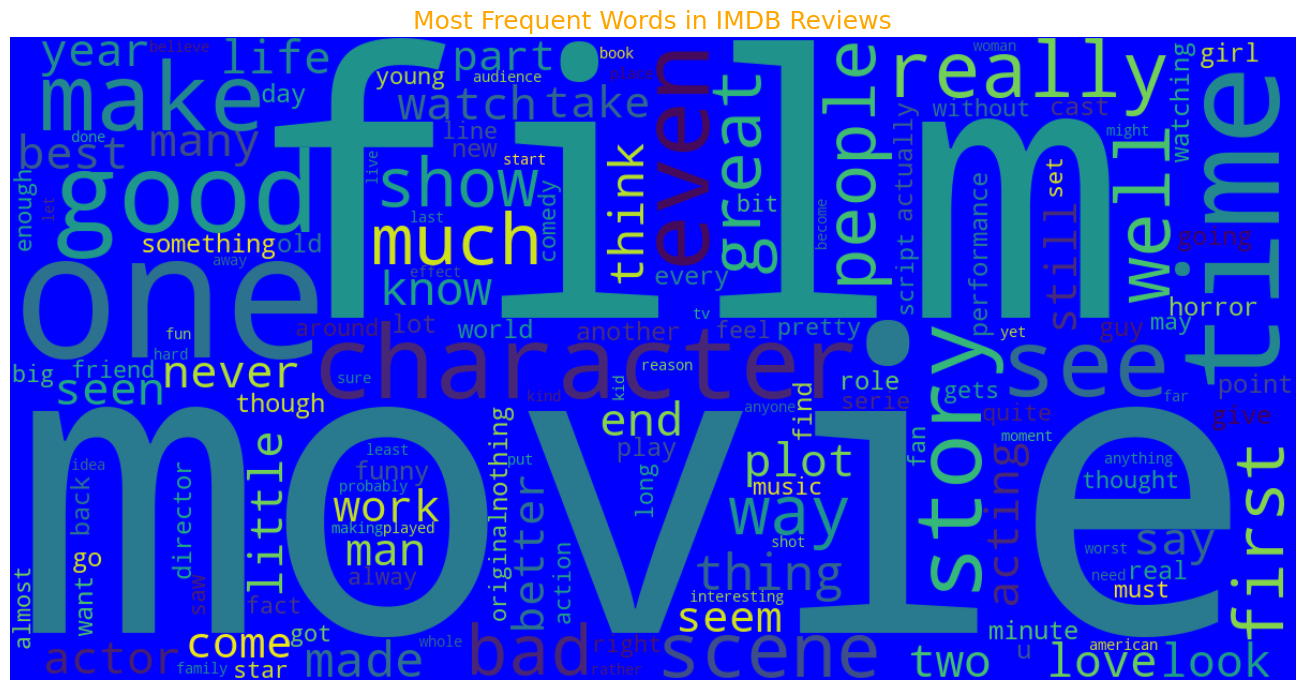

In [32]:
text = " ".join(df["clean_review"])
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="blue",
    max_words=150,
    collocations=False
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in IMDB Reviews", color = 'orange', fontsize = 18)
plt.tight_layout()
plt.show()

# Positive WordCloud

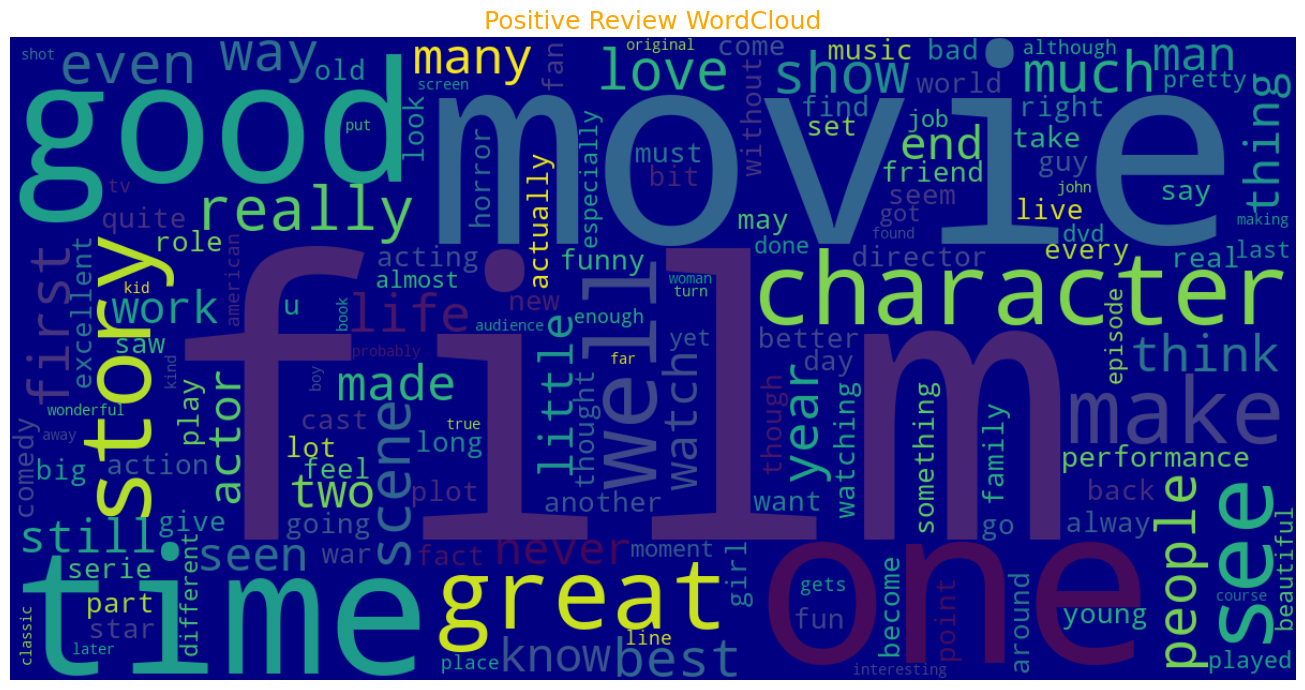

In [33]:
positive_wc = WordCloud(
    width=1200,
    height=600,
    background_color="navy",
    max_words=150,
    collocations=False
).generate(positive_text)

plt.figure(figsize=(15,7))
plt.imshow(positive_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Review WordCloud", color = 'orange', fontsize = 18)
plt.tight_layout()
plt.show()

# Negative WordCloud

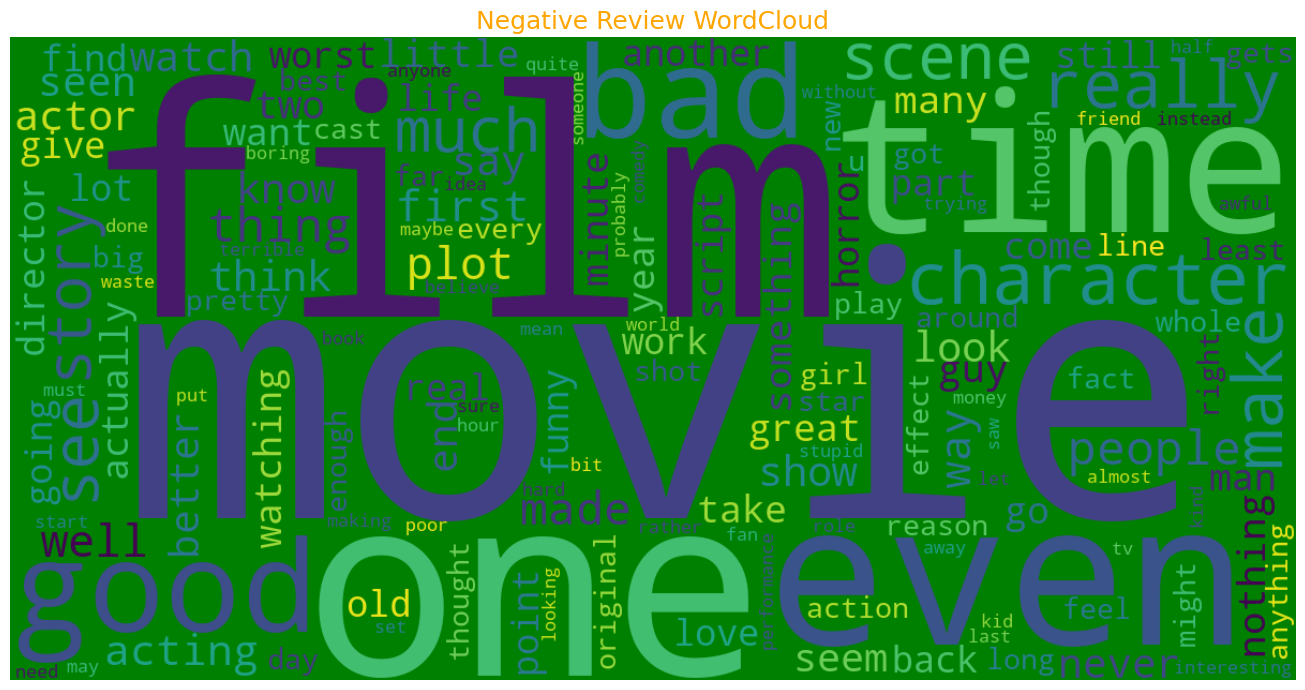

In [34]:
negative_wc = WordCloud(
    width=1200,
    height=600,
    background_color="green",
    max_words=150,
    collocations=False
).generate(negative_text)

plt.figure(figsize=(15,7))
plt.imshow(negative_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Review WordCloud", color = 'orange', fontsize = 18)
plt.tight_layout()
plt.show()

# Lemmatization

`lemmatize_text` lemmatizes each word as a noun and then as a verb (movies → movie, loved → love).

In [35]:
df['lemmatized_text'] = df['clean_review'].apply(lemmatize_text)
df[['clean_review', 'lemmatized_text']].head()

,clean_review,lemmatized_text
0,one reviewers mentioned watching oz episode ho...,one reviewer mention watch oz episode hook rig...
1,wonderful little production filming technique ...,wonderful little production film technique ver...
2,thought wonderful way spend time too hot summe...,think wonderful way spend time too hot summer ...
3,basically family little boy jake thinks zombie...,basically family little boy jake think zombie ...
4,petter mattei love time money visually stunnin...,petter mattei love time money visually stun fi...


# Save Cleaned Dataset

In [36]:
output_file = DATA_DIR / "Cleaned IMDB Dataset.csv"
df.to_csv(output_file, index=False)
print(f"Cleaned dataset successfully saved to:\n{output_file}")
print("Final shape:", df.shape)

Cleaned dataset successfully saved to:
D:\classical-nlp-streamlit-project\nlp-project\Data\Cleaned IMDB Dataset.csv
Final shape: (49582, 8)
